# support vector machine:

support vector machine (SVM) is a supervised machine learning algorithm used for classification regression that finds optimal hyperplane which separates 
data points of different classes with the maximum margin.

  ### Types of support vector machine:
  Based on the nature of the decision boundary, supporgt vector machine(SVM) can be divided into two main parts:

### Linear SVM:
linear svm use a linear decision boundary to separate the data points of different classes. When the data can be precisely linearly separated, linear 
SVMs are very suitable. This means that a sinle straight line (in 2D) or a hyperplan (in higher dimension) can entirely divide the data points into their
respective classes. A hyperplane that maximizes the margin between the classes is the decision boundary.

### Non-Linear SVM:
Non-Linear SVM can be used to classify data when it cannot be separated into two classes by a straight line( in the case of 2D). By using kernal fuctions,
nonlinear SVMs can handle nonlinearly separable data. The original input data is transformed by these kernal functions into a Higher-dimensional feature 
space where the data points can belinearly separated. A linear SVM is used to locate a nonlinear decisin boundary in this modifed space.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC

In [2]:
data = {
    "Study_Hours": [2, 3, 5, 6, 7],
    "Attendance": [60, 65, 75, 80, 85],
    "Result": ["Fail", "Fail", "Pass", "Pass", "Pass"]
}

df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance Result
0            2          60   Fail
1            3          65   Fail
2            5          75   Pass
3            6          80   Pass
4            7          85   Pass


In [3]:
df["Result"] = df["Result"].map({"Fail": 0, "Pass": 1})
print(df)

   Study_Hours  Attendance  Result
0            2          60       0
1            3          65       0
2            5          75       1
3            6          80       1
4            7          85       1


In [4]:
X = df[["Study_Hours", "Attendance"]]   # features
y = df ["Result"]    # target

In [5]:
model = SVC(kernel="linear")
model.fit(X, y)

SVC(kernel='linear')

In [6]:
w = model.coef_[0]
b = model.intercept_[0]

print(w)
print(b)

[0.03846154 0.19230769]
-13.615384615384613


In [7]:
new_student = pd.DataFrame({
    "Study_Hours": [4],
    "Attendance": [70]

})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")

Prediction: Pass


In [8]:
x_vals = np.linspace(X["Study_Hours"].min()-1, X["Study_Hours"].max()+1, 100)
#(w1*x1+b)/w2
y_vals = -(w[0] * x_vals + b) / w[1]

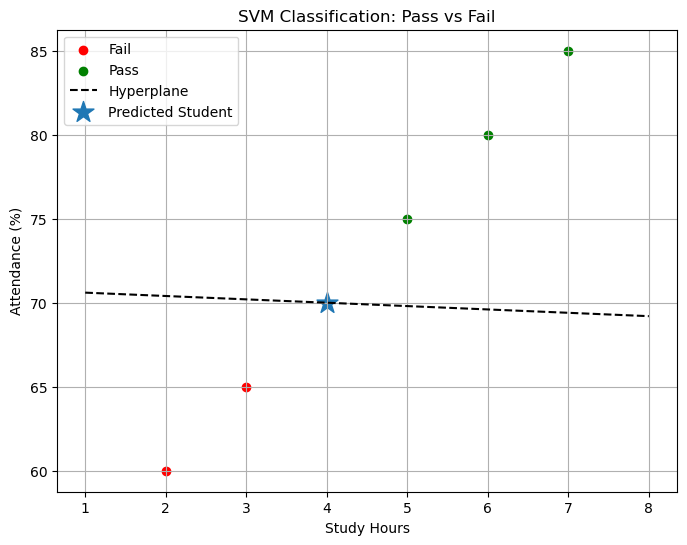

In [9]:
plt.figure(figsize=(8, 6))

# Separate data
fail = df[df.iloc[:, 2] == 0]   # Result column
pass_ = df[df.iloc[:, 2] == 1]

# Fail points
plt.scatter(
    fail.iloc[:, 0],   # Study Hours
    fail.iloc[:, 1],   # Attendance
    color="red",
    label="Fail"
)

# Pass points
plt.scatter(
    pass_.iloc[:, 0],
    pass_.iloc[:, 1],
    color="green",
    label="Pass"
)

# Hyperplane
plt.plot(x_vals, y_vals, "k--", label="Hyperplane")

# Predicted point (NUMPY ARRAY)
plt.scatter(
    new_student.iloc[0, 0],
    new_student.iloc[0, 1],
    marker="*",
    s=250,
    label="Predicted Student"
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("SVM Classification: Pass vs Fail")
plt.legend()
plt.grid(True)
plt.show()